In [2]:
# List files to find the relevant CSV for loading
def list_files_in_dir(directory="."):
    import os
    files = []
    for f in os.listdir(directory):
        if os.path.isfile(os.path.join(directory, f)):
            files.append(f)
    return files

# List current directory contents (look for CSVs)
list_files_in_dir()

['Untitled spreadsheet - PLNT23.csv',
 'LICENSE',
 'simulations.py',
 'README.md',
 'modelTesting.ipynb']

In [3]:
# Load the CSV into a pandas DataFrame, inspect first few rows and dtypes to initiate EDA
import pandas as pd

df = pd.read_csv('Untitled spreadsheet - PLNT23.csv')
display(df.head())
print(df.dtypes)

/var/folders/4c/rg1h67_11_n4pg2t3_swv4h00000gn/T/ipykernel_30969/3608977287.py:4: DtypeWarning: Columns (0,1,4,6,8,16,17,19,20,22,23,27,29,33,34,35,50,51,52,53,55,56,58,59,60,61,62,63,64,65,66,67,68,69,71,72,74,82,85,86,97,98,99,102,107,122) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Untitled spreadsheet - PLNT23.csv')


,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%


Plant file sequence number                                                             object
Data Year                                                                              object
Plant state abbreviation                                                               object
Plant name                                                                             object
DOE/EIA ORIS plant or facility code                                                    object
                                                                                        ...  
Plant total nonrenewables other unknown/purchased generation percent (resource mix)    object
Plant total nonhydro renewables generation percent (resource mix)                      object
Plant total combustion generation percent (resource mix)                               object
Plant total noncombustion generation percent (resource mix)                            object
Plant total noncombustion other unknown/purchased generation

In [4]:
# Display all column names to map to optimization criteria
pd.set_option('display.max_columns', None)
print(df.columns.tolist())

# Also explicitly print first row to check for possible extra header row
print('First row:', df.iloc[0].values)


['Plant file sequence number', 'Data Year', 'Plant state abbreviation', 'Plant name', 'DOE/EIA ORIS plant or facility code', 'Plant transmission or distribution system owner name', 'Plant transmission or distribution system owner ID', 'Utility name', 'Utility ID', 'Plant-level sector', 'Balancing Authority Name', 'Balancing Authority Code', 'NERC region acronym', 'eGRID subregion acronym', 'eGRID subregion name', 'Plant associated ISO/RTO Territory', 'Plant FIPS state code', 'Plant FIPS county code', 'Plant county name', 'Plant latitude', 'Plant longitude', 'CAPD Program Flag', 'Number of units', 'Number of generators', 'Plant primary fuel', 'Plant primary fuel category', 'Flag indicating if the plant burned or generated any amount of coal', 'Plant capacity factor', 'Plant nameplate capacity (MW)', 'Nonbaseload Factor', 'Biogas/ biomass plant adjustment flag', 'Combined heat and power (CHP) plant adjustment flag', 'CHP plant useful thermal output (MMBtu)', 'CHP plant power to heat rati

In [5]:
# Remove duplicate header (row 0), reset index, and prepare for analysis
# Also cast numeric columns to float where possible (needed for later stats/EDA)
df_clean = df.iloc[1:].reset_index(drop=True)

# Identify potentially relevant columns for each optimization parameter
columns_of_interest = [
    'Plant latitude', 'Plant longitude', 'Plant primary fuel category', 
    'Plant nameplate capacity (MW)', 'Plant annual net generation (MWh)',
    'Plant annual total renewables net generation (MWh)',
    'Plant annual total nonrenewables net generation (MWh)',
    'Plant annual total renewables other unknown/purchased net generation (MWh)',
    'Plant annual coal net generation (MWh)', 'Plant annual oil net generation (MWh)',
    'Plant annual gas net generation (MWh)', 'Plant capacity factor',
    # Generation percent columns for sustainability
    'Plant coal generation percent (resource mix)', 'Plant oil generation percent (resource mix)',
    'Plant gas generation percent (resource mix)', 'Plant nuclear generation percent (resource mix)',
    'Plant hydro generation percent (resource mix)', 'Plant biomass generation percent (resource mix)',
    'Plant wind generation percent (resource mix)', 'Plant solar generation percent (resource mix)',
    'Plant geothermal generation percent (resource mix)',
]

# Print relevant sample & data types after cleaning
display(df_clean[columns_of_interest].head())
print(df_clean[columns_of_interest].dtypes)
print('\nRows:', len(df_clean))

,Plant latitude,Plant longitude,Plant primary fuel category,Plant nameplate capacity (MW),Plant annual net generation (MWh),Plant annual total renewables net generation (MWh),Plant annual total nonrenewables net generation (MWh),Plant annual total renewables other unknown/purchased net generation (MWh),Plant annual coal net generation (MWh),Plant annual oil net generation (MWh),Plant annual gas net generation (MWh),Plant capacity factor,Plant coal generation percent (resource mix),Plant oil generation percent (resource mix),Plant gas generation percent (resource mix),Plant nuclear generation percent (resource mix),Plant hydro generation percent (resource mix),Plant biomass generation percent (resource mix),Plant wind generation percent (resource mix),Plant solar generation percent (resource mix),Plant geothermal generation percent (resource mix)
0,62.6833,-164.6544,OIL,0.8,0,0,0,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,61.084444,-146.353333,HYDRO,6.5,"20,961","20,961",0,0,0,0,0,0.3681,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%
2,67.08798,-157.856719,OIL,1.1,"1,239",0,"1,239",0,0,"1,239",0,0.1286,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
3,57.499166,-134.58614,OIL,1.5,"1,816",0,"1,816",0,0,"1,816",0,0.1382,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
4,61.580678,-159.535643,OIL,1.7,"2,017",0,"2,017",0,0,"2,017",0,0.1354,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


Plant latitude                                                                object
Plant longitude                                                               object
Plant primary fuel category                                                   object
Plant nameplate capacity (MW)                                                 object
Plant annual net generation (MWh)                                             object
Plant annual total renewables net generation (MWh)                            object
Plant annual total nonrenewables net generation (MWh)                         object
Plant annual total renewables other unknown/purchased net generation (MWh)    object
Plant annual coal net generation (MWh)                                        object
Plant annual oil net generation (MWh)                                         object
Plant annual gas net generation (MWh)                                         object
Plant capacity factor                                            

Plant primary fuel category distribution:
Plant primary fuel category
SOLAR         5658
GAS           1993
HYDRO         1459
WIND          1334
OIL            878
BIOMASS        628
OTHF           301
COAL           222
GEOTHERMAL      67
NUCLEAR         54
OFSL            18
Name: count, dtype: int64

Top 10 plants by capacity:


,Plant name,Plant nameplate capacity (MW),Plant nameplate capacity (MW)_num
12173,Grand Coulee,"6,809.0",6809.0
2952,West County Energy Center,"4,263.0",4263.0
413,Palo Verde,"4,209.6",4209.6
11547,W A Parish,"4,008.4",4008.4
163,Browns Ferry,"3,854.0",3854.0
3189,Vogtle,"3,544.0",3544.0
2981,Bowen,"3,498.6",3498.6
2744,Crystal River,"3,449.0",3449.0
159,Barry,"3,343.5",3343.5
4105,Gibson,"3,339.5",3339.5


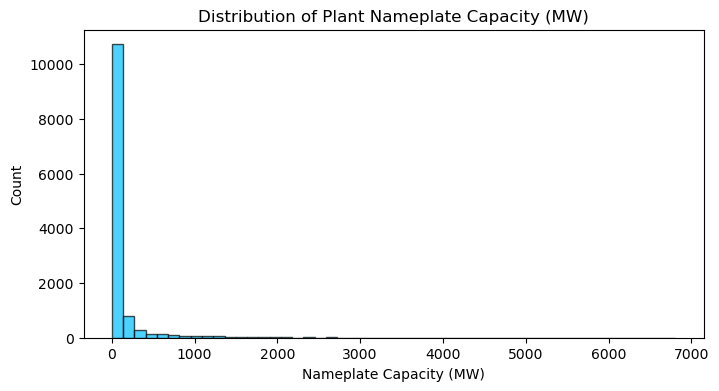

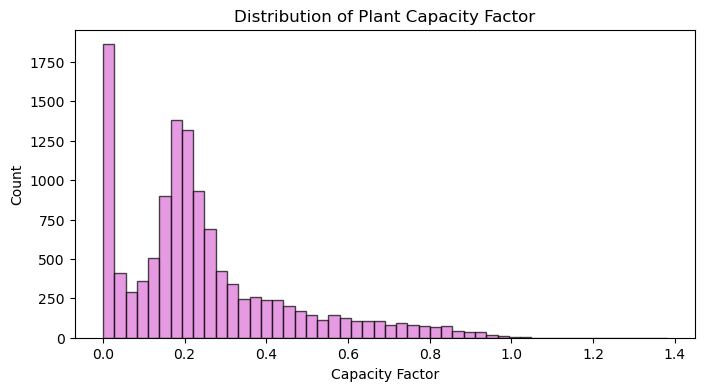

count    12239.000000
mean         0.244147
std          0.204673
min          0.000000
25%          0.119700
50%          0.201300
75%          0.311100
max          1.379800
Name: Plant capacity factor_num, dtype: float64


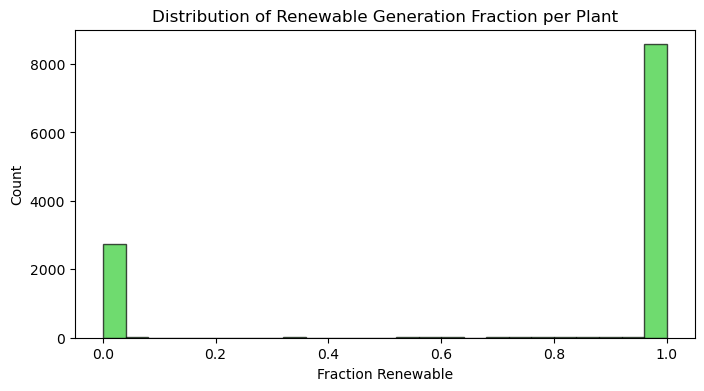


Summary stats for renewable fraction:
count    11504.000000
mean         0.756336
std          0.426162
min          0.000000
25%          0.872750
50%          1.000000
75%          1.000000
max          1.000000
Name: renew_frac, dtype: float64


In [6]:
# Exploratory Data Analysis on relevant ML axes
import matplotlib.pyplot as plt
import numpy as np

# Helper to coerce string numbers with commas, percents

def parse_number(x):
    if pd.isna(x): return np.nan
    if isinstance(x, str):
        x = x.replace(',', '').replace('%','')
        try:
            return float(x)
        except:
            return np.nan
    return x

# 1. Distribution of renewable/clean vs nonrenewable (by fuel category)
cat_counts = df_clean['Plant primary fuel category'].value_counts(dropna=False)
print('Plant primary fuel category distribution:')
print(cat_counts)

# 2. Top plants by nameplate capacity
cap_col = 'Plant nameplate capacity (MW)'
df_clean[cap_col + '_num'] = df_clean[cap_col].apply(parse_number)
print('\nTop 10 plants by capacity:')
display(df_clean[['Plant name', cap_col, cap_col + '_num']].sort_values(cap_col + '_num', ascending=False).head(10))

plt.figure(figsize=(8,4))
plt.hist(df_clean[cap_col + '_num'].dropna(), bins=50, color='deepskyblue', edgecolor='k', alpha=0.7)
plt.title('Distribution of Plant Nameplate Capacity (MW)')
plt.xlabel('Nameplate Capacity (MW)')
plt.ylabel('Count')
plt.show()

# 3. Best available capacity factor (proxy for lowest cost per MWh)
capfac_col = 'Plant capacity factor'
df_clean[capfac_col + '_num'] = df_clean[capfac_col].apply(parse_number)
plt.figure(figsize=(8,4))
plt.hist(df_clean[capfac_col + '_num'].dropna(), bins=50, color='orchid', edgecolor='k', alpha=0.7)
plt.title('Distribution of Plant Capacity Factor')
plt.xlabel('Capacity Factor')
plt.ylabel('Count')
plt.show()

print(df_clean[capfac_col + '_num'].describe())

# 4. Fraction of renewables/nonrenewables by plant (for ML sustainability feature)
renew_cols = [
    'Plant coal generation percent (resource mix)',
    'Plant oil generation percent (resource mix)',
    'Plant gas generation percent (resource mix)',
    'Plant nuclear generation percent (resource mix)',
    'Plant hydro generation percent (resource mix)',
    'Plant biomass generation percent (resource mix)',
    'Plant wind generation percent (resource mix)',
    'Plant solar generation percent (resource mix)',
    'Plant geothermal generation percent (resource mix)'
]
def get_renewable_frac(row):
    renw = 0
    total = 0
    for c in renew_cols:
        v = parse_number(row.get(c, np.nan))
        if pd.isna(v): continue
        total += v
        if 'hydro' in c.lower() or 'wind' in c.lower() or 'solar' in c.lower() or 'biomass' in c.lower() or 'geothermal' in c.lower():
            renw += v
    if total == 0: return np.nan
    return renw/total

df_clean['renew_frac'] = df_clean.apply(get_renewable_frac, axis=1)
plt.figure(figsize=(8,4))
plt.hist(df_clean['renew_frac'].dropna(), bins=25, color='limegreen', edgecolor='k', alpha=0.7)
plt.title('Distribution of Renewable Generation Fraction per Plant')
plt.xlabel('Fraction Renewable')
plt.ylabel('Count')
plt.show()

print('\nSummary stats for renewable fraction:')
print(df_clean['renew_frac'].describe())

In [9]:
# Updated recommend_datacenter_radius to explicitly print capacities and sort by LOWEST utilization for more headroom
import numpy as np

def recommend_datacenter_radius(df, required_mw, state_abbr, min_renew_frac=0.5, n_best=5):
    plants_in_region = df[(df['Plant state abbreviation'] == state_abbr.upper())].copy()
    for field in ['Plant nameplate capacity (MW)_num', 'renew_frac', 'Plant capacity factor_num']:
        plants_in_region[field] = plants_in_region[field].apply(lambda x: np.nan if pd.isna(x) else float(x))
    
    suitable = plants_in_region[(plants_in_region['Plant nameplate capacity (MW)_num'] >= required_mw) & 
                                (plants_in_region['renew_frac'] >= min_renew_frac)]
    if suitable.empty:
        print('No suitable plant found in region meeting all requirements.')
        return None
    # Sort by lowest capacity factor (i.e., plants with the most headroom to serve new demand)
    top = suitable.sort_values('Plant capacity factor_num', ascending=True).head(n_best)
    # Compute central point (mean lat/lon) and radius
    lats = top['Plant latitude'].astype(float)
    lons = top['Plant longitude'].astype(float)
    center_lat, center_lon = lats.mean(), lons.mean()
    def haversine(lat1, lon1, lat2, lon2):
        from math import radians, sin, cos, sqrt, atan2
        R = 6371  # km
        dlat = radians(lat2-lat1)
        dlon = radians(lon2-lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c
    radius = max([haversine(center_lat, center_lon, lat, lon) for lat, lon in zip(lats, lons)])

    # Add a margin column: remaining (nameplate - required)
    top['capacity_margin'] = top['Plant nameplate capacity (MW)_num'] - required_mw

    print(f'For required {required_mw} MW in {state_abbr} (renew_frac>{min_renew_frac}):')
    print(f'Optimal central point: ({center_lat:.4f}, {center_lon:.4f}), Required radius: {radius:.2f} km')
    print('Top candidate plants (sorted by LOWEST current utilization/capacity factor):')
    display(top[[
        'Plant name',
        'Plant nameplate capacity (MW)_num',
        'capacity_margin',
        'renew_frac',
        'Plant capacity factor_num',
    ]])
    return center_lat, center_lon, radius, top # return selected dataframe for further analysis if needed

# Example usage (adjust as needed)
recommend_datacenter_radius(df_clean, required_mw=50, state_abbr='NY', min_renew_frac=0.8)


For required 50 MW in NY (renew_frac>0.8):
Optimal central point: (43.6253, -75.5919), Required radius: 321.11 km
Top candidate plants (sorted by LOWEST current utilization/capacity factor):


,Plant name,Plant nameplate capacity (MW)_num,capacity_margin,renew_frac,Plant capacity factor_num
8707,"Bluestone Wind, LLC",111.8,61.8,1.000000,0.0521
8673,"Ball Hill Wind Energy, LLC",107.5,57.5,1.000000,0.0528
8790,Clinton,100.5,50.5,1.000000,0.1398
8650,Altona,97.5,47.5,1.000000,0.1407
8698,"Black River Generation, LLC",55.5,5.5,0.998987,0.1475


(np.float64(43.6252978),
 np.float64(-75.5918682),
 321.1058703955046,
      Plant file sequence number Data Year Plant state abbreviation  \
 8707                       8708      2023                       NY   
 8673                       8674      2023                       NY   
 8790                       8791      2023                       NY   
 8650                       8651      2023                       NY   
 8698                       8699      2023                       NY   
 
                        Plant name DOE/EIA ORIS plant or facility code  \
 8707          Bluestone Wind, LLC                               65496   
 8673   Ball Hill Wind Energy, LLC                               65495   
 8790                      Clinton                               56618   
 8650                       Altona                               56901   
 8698  Black River Generation, LLC                               10464   
 
      Plant transmission or distribution system owner n

For required 50 MW in NY (renew_frac>0.8):
Optimal central point: (43.6253, -75.5919), Required radius: 321.11 km
Top candidate plants (sorted by LOWEST current utilization/capacity factor):


,Plant name,Plant nameplate capacity (MW)_num,capacity_margin,renew_frac,Plant capacity factor_num
8707,"Bluestone Wind, LLC",111.8,61.8,1.000000,0.0521
8673,"Ball Hill Wind Energy, LLC",107.5,57.5,1.000000,0.0528
8790,Clinton,100.5,50.5,1.000000,0.1398
8650,Altona,97.5,47.5,1.000000,0.1407
8698,"Black River Generation, LLC",55.5,5.5,0.998987,0.1475


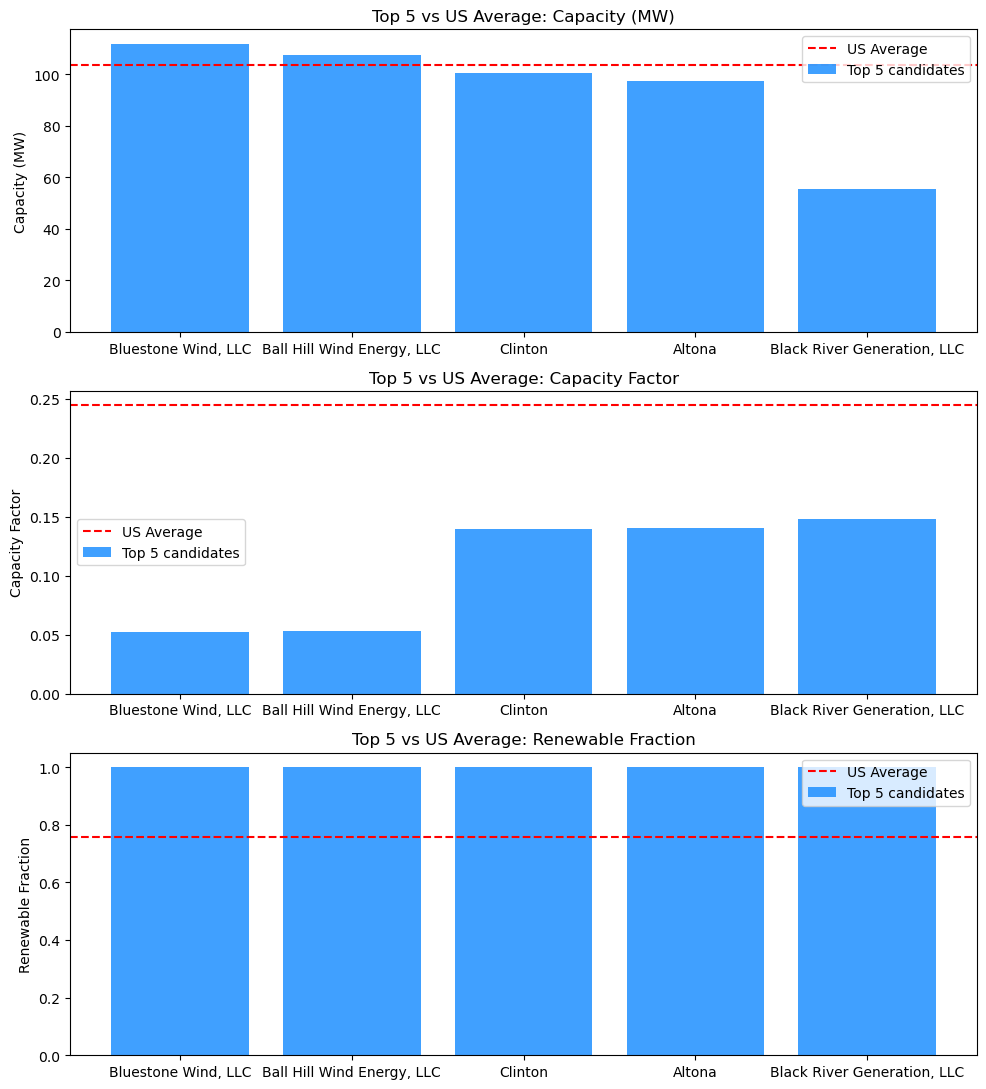

In [10]:
# Compare top 5 suggested plants for siting to US averages on key axes
import matplotlib.pyplot as plt

# Suppose we are using the previous top 5 (from NY). You can change this selection logic as needed.
top5 = recommend_datacenter_radius(df_clean, required_mw=50, state_abbr='NY', min_renew_frac=0.8, n_best=5)[3]

# US (full dataset) averages
avg_capacity = df_clean['Plant nameplate capacity (MW)_num'].mean()
avg_cf = df_clean['Plant capacity factor_num'].mean()
avg_renew = df_clean['renew_frac'].mean()

top_caps = top5['Plant nameplate capacity (MW)_num']
top_cf = top5['Plant capacity factor_num']
top_renew = top5['renew_frac']

labels = top5['Plant name']
params = ['Capacity (MW)', 'Capacity Factor', 'Renewable Fraction']

data = [
    top_caps.values,
    top_cf.values,
    top_renew.values,
]
avgs = [avg_capacity, avg_cf, avg_renew]

fig, axs = plt.subplots(3, 1, figsize=(10, 11))
for i, (series, param, avg) in enumerate(zip(data, params, avgs)):
    axs[i].bar(labels, series, color='dodgerblue', alpha=0.85, label='Top 5 candidates')
    axs[i].axhline(avg, color='red', linestyle='--', label='US Average')
    axs[i].set_ylabel(param)
    axs[i].set_title(f'Top 5 vs US Average: {param}')
    axs[i].legend()
plt.tight_layout()
plt.show()